In [2]:
# Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving marketing_campaign.csv to marketing_campaign.csv


In [4]:
# Load Dataset

df = pd.read_csv("marketing_campaign.csv", sep="\t")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
# Display Dataset

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
# Dataset Shape
print("Rows and Columns:", df.shape)

Rows and Columns: (2240, 29)


In [7]:
# Column Names
print(df.columns.tolist())

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [8]:
# Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [9]:
# Summary Statistics
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [10]:
# Missing Values
missing_values = df.isnull().sum()

missing_values

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


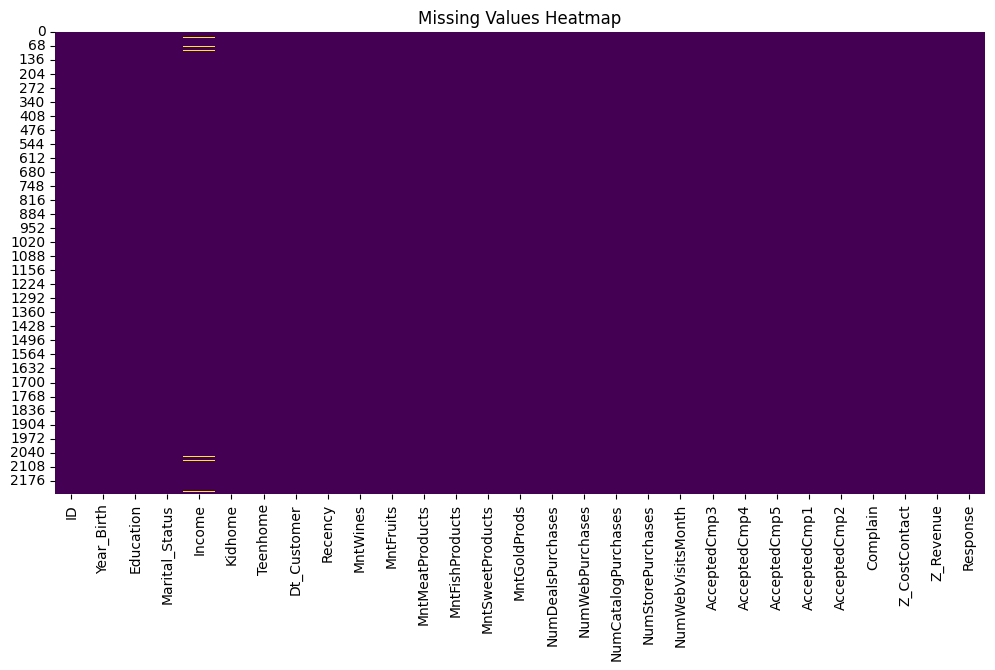

In [11]:
# Missing Values Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

In [ ]:
# Dataset Exploration

# In this part, the Customer Personality Analysis dataset was imported into Google Colab and inspected.

# The dataset structure, dimensions, data types, summary statistics, and missing values were examined to understand the quality of the data before preprocessing.

# This exploratory step helps identify potential issues that need to be addressed before applying clustering algorithms.

In [12]:
# A Copy of Dataset
df_clean = df.copy()

print("Dataset Copied Successfully!")

Dataset Copied Successfully!


In [13]:
df_clean["Income"].isnull().sum()

np.int64(24)

In [14]:
# Fill Missing Income Values
df_clean["Income"].fillna(
    df_clean["Income"].median(),
    inplace=True
)

print("Missing Income Values Filled!")

Missing Income Values Filled!


In [15]:
df_clean.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [16]:
# Drop Unnecessary Columns
df_clean.drop(
    columns=[
        "ID",
        "Z_CostContact",
        "Z_Revenue"
    ],
    inplace=True
)

print("Columns Removed Successfully!")

Columns Removed Successfully!


In [17]:
# Convert Date Column
df_clean["Dt_Customer"] = pd.to_datetime(
    df_clean["Dt_Customer"],
    dayfirst=True
)

In [18]:
# Customer Tenure
latest_date = df_clean["Dt_Customer"].max()

df_clean["Customer_For_Days"] = (
    latest_date - df_clean["Dt_Customer"]
).dt.days

In [19]:
df_clean.drop(
    "Dt_Customer",
    axis=1,
    inplace=True
)

In [20]:
# Encode Education
from sklearn.preprocessing import LabelEncoder

le_education = LabelEncoder()

df_clean["Education"] = le_education.fit_transform(
    df_clean["Education"]
)

In [21]:
# Encode Marital Status
le_marital = LabelEncoder()

df_clean["Marital_Status"] = le_marital.fit_transform(
    df_clean["Marital_Status"]
)

In [22]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   int64  
 2   Marital_Status       2240 non-null   int64  
 3   Income               2240 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Recency              2240 non-null   int64  
 7   MntWines             2240 non-null   int64  
 8   MntFruits            2240 non-null   int64  
 9   MntMeatProducts      2240 non-null   int64  
 10  MntFishProducts      2240 non-null   int64  
 11  MntSweetProducts     2240 non-null   int64  
 12  MntGoldProds         2240 non-null   int64  
 13  NumDealsPurchases    2240 non-null   int64  
 14  NumWebPurchases      2240 non-null   int64  
 15  NumCatalogPurchases  2240 non-null   i

In [23]:
df_clean.isnull().sum()

,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0


In [24]:
df_clean.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For_Days
0,1957,2,4,58138.0,0,0,58,635,88,546,...,4,7,0,0,0,0,0,0,1,663
1,1954,2,4,46344.0,1,1,38,11,1,6,...,2,5,0,0,0,0,0,0,0,113
2,1965,2,5,71613.0,0,0,26,426,49,127,...,10,4,0,0,0,0,0,0,0,312
3,1984,2,5,26646.0,1,0,26,11,4,20,...,4,6,0,0,0,0,0,0,0,139
4,1981,4,3,58293.0,1,0,94,173,43,118,...,6,5,0,0,0,0,0,0,0,161


In [ ]:
# Data Cleaning & Preprocessing

# In this part, missing values in the `Income` column were handled using median imputation to reduce the influence of outliers.

# Columns that did not contribute to customer segmentation (`ID`, `Z_CostContact`, and `Z_Revenue`) were removed.

# The `Dt_Customer` column was converted into a numerical feature (`Customer_For_Days`) representing customer tenure.

# Categorical features (`Education` and `Marital_Status`) were encoded into numerical values using Label Encoding.

# The resulting dataset contains only numerical features, making it suitable for PCA and K-Means clustering.

In [25]:
# Summary Statistics
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Education,2240.0,2.393750,1.124797,0.0,2.00,2.0,3.00,4.0
Marital_Status,2240.0,3.729911,1.076277,0.0,3.00,4.0,5.00,7.0
Income,2240.0,52237.975446,25037.955891,1730.0,35538.75,51381.5,68289.75,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0


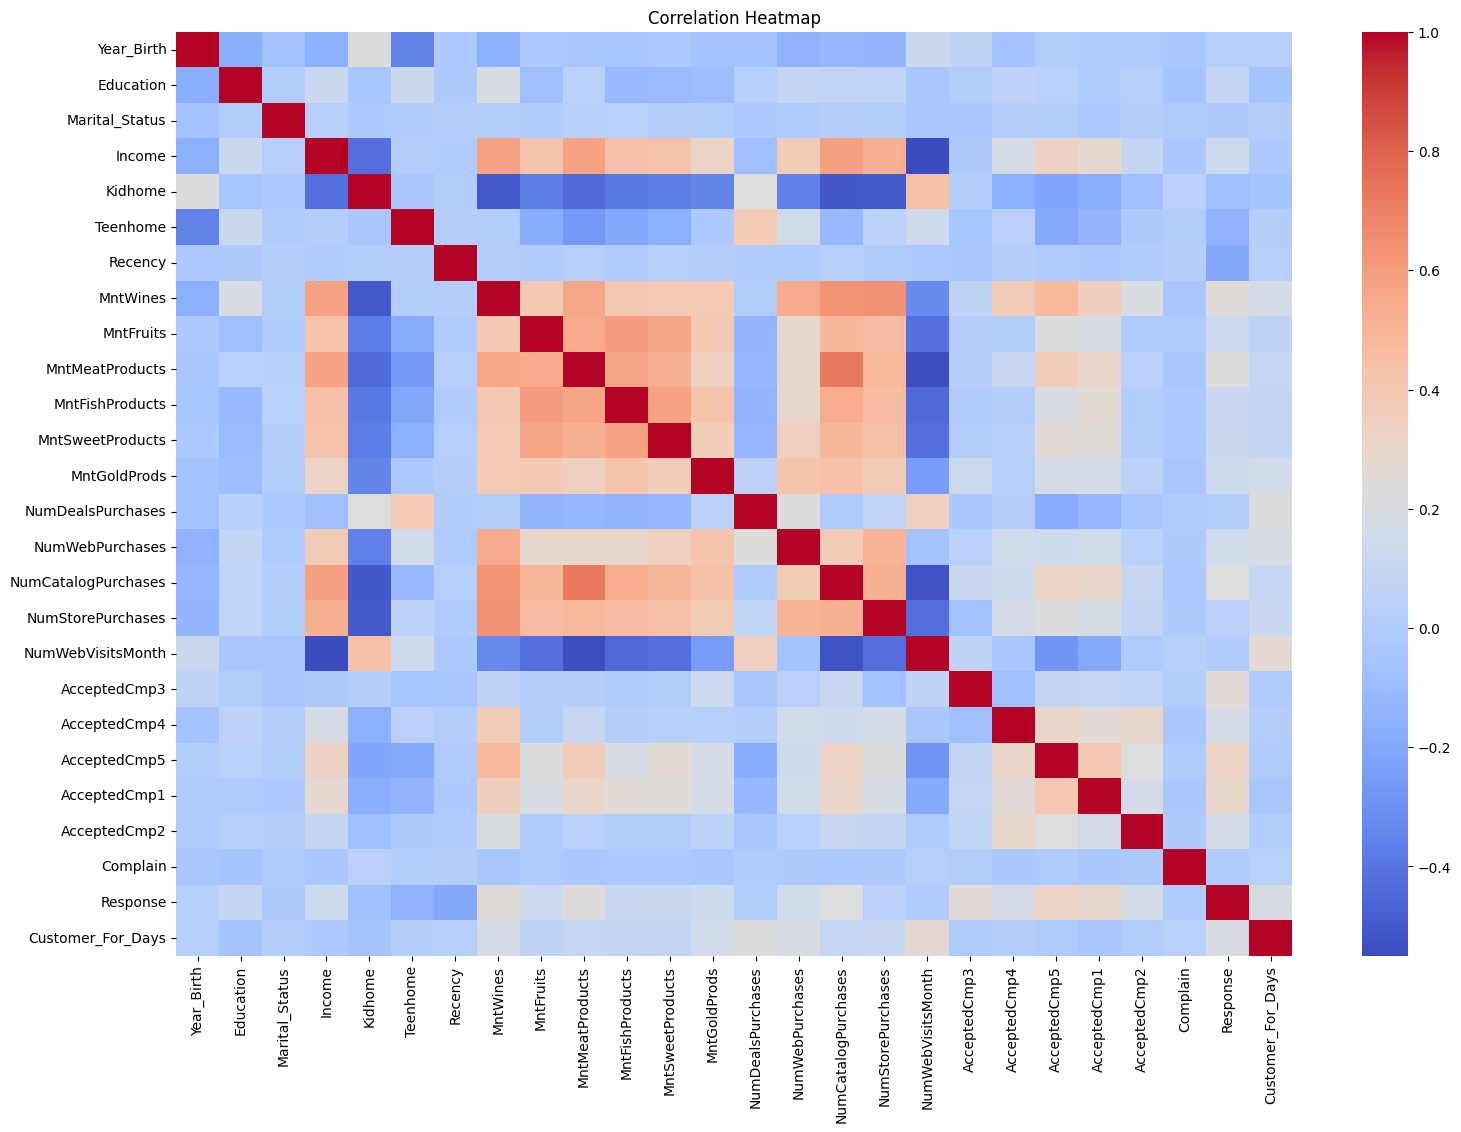

In [26]:
# Correlation Heatmap
plt.figure(figsize=(18,12))

sns.heatmap(
    df_clean.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

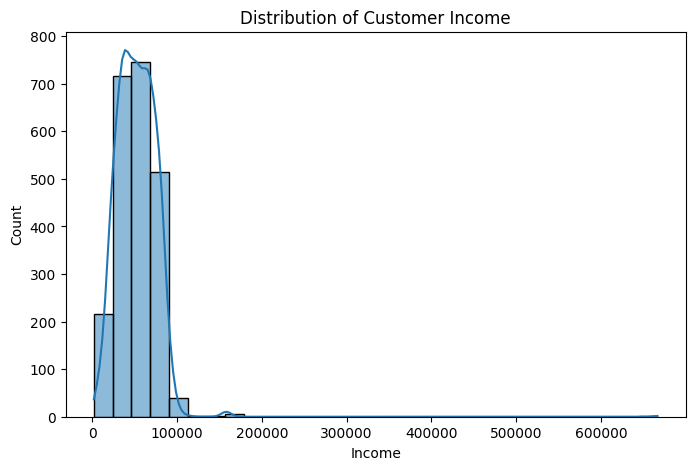

In [27]:
# Income Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Income"],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Income")

plt.show()

In [28]:
# Total Spending
df_clean["Total_Spending"] = (
    df_clean["MntWines"]
    + df_clean["MntFruits"]
    + df_clean["MntMeatProducts"]
    + df_clean["MntFishProducts"]
    + df_clean["MntSweetProducts"]
    + df_clean["MntGoldProds"]
)

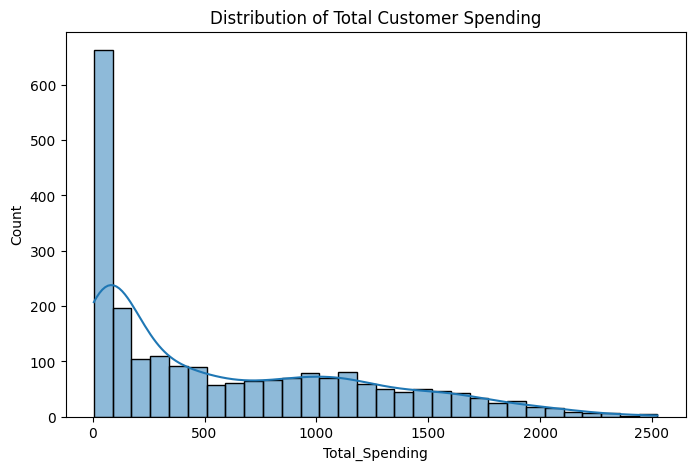

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Total_Spending"],
    bins=30,
    kde=True
)

plt.title("Distribution of Total Customer Spending")

plt.show()

In [30]:
# Total Purchases
df_clean["Total_Purchases"] = (
    df_clean["NumWebPurchases"]
    + df_clean["NumCatalogPurchases"]
    + df_clean["NumStorePurchases"]
)

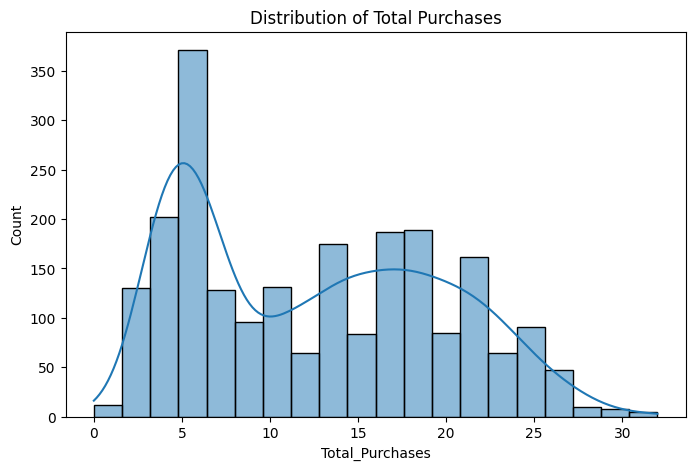

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Total_Purchases"],
    bins=20,
    kde=True
)

plt.title("Distribution of Total Purchases")

plt.show()

In [32]:
# Customer Age
current_year = 2026

df_clean["Age"] = current_year - df_clean["Year_Birth"]

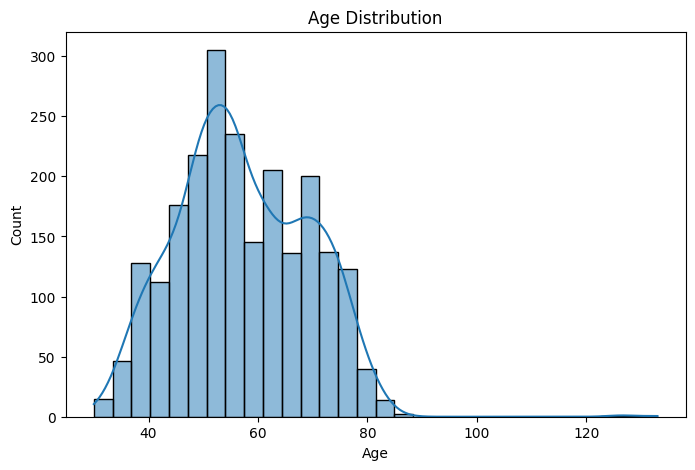

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

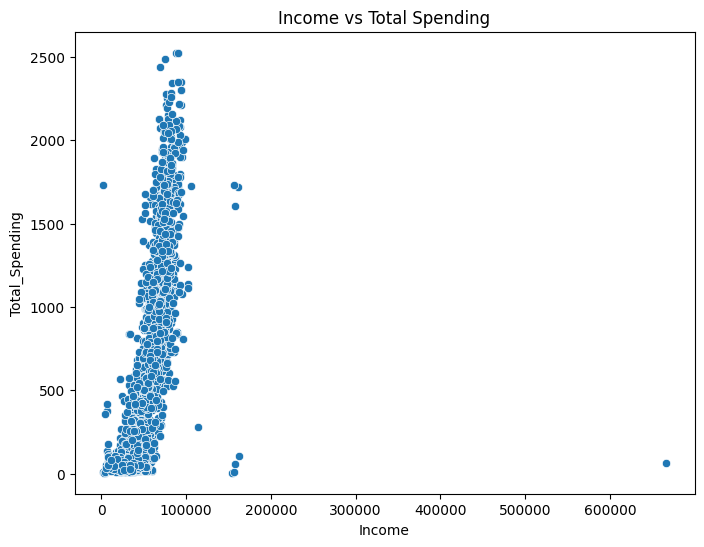

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Income",
    y="Total_Spending",
    data=df_clean
)

plt.title("Income vs Total Spending")

plt.show()

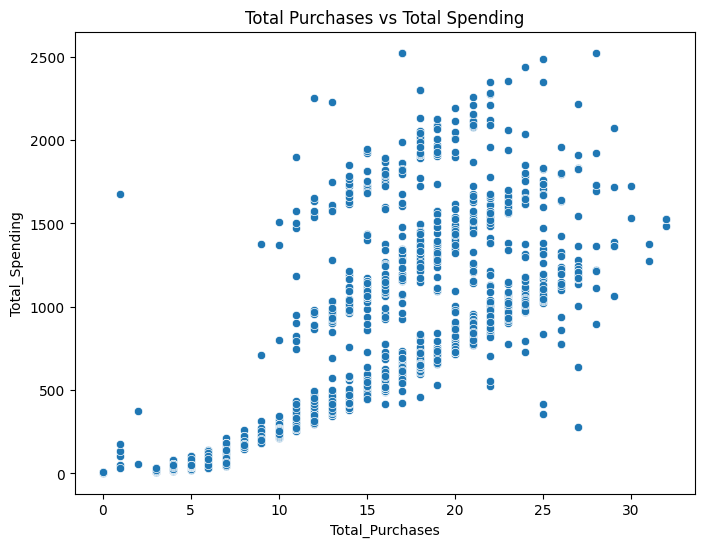

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Total_Purchases",
    y="Total_Spending",
    data=df_clean
)

plt.title("Total Purchases vs Total Spending")

plt.show()

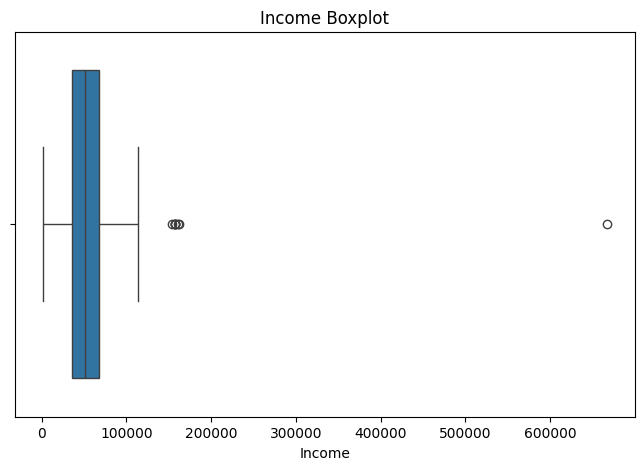

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_clean["Income"]
)

plt.title("Income Boxplot")

plt.show()

In [ ]:
# Exploratory Data Analysis

# The cleaned dataset was explored to understand customer characteristics before clustering.

# Several visualizations were created to examine feature distributions, correlations, income levels, spending behavior, purchase activity, and potential outliers.

# Additional features (`Total_Spending`, `Total_Purchases`, and `Age`) were engineered to provide richer customer information for the clustering process.

In [37]:
# Feature Matrix
X = df_clean.copy()

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (2240, 29)


In [38]:
# Feature Names
print(X.columns.tolist())

['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Customer_For_Days', 'Total_Spending', 'Total_Purchases', 'Age']


In [39]:
# Standardize Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data Standardized Successfully!")

Data Standardized Successfully!


In [40]:
# Check Shape
print("Scaled Data Shape:", X_scaled.shape)

Scaled Data Shape: (2240, 29)


In [41]:
# Mean of Scaled Data
print(np.round(X_scaled.mean(axis=0), 2))

[-0.  0. -0. -0. -0. -0. -0. -0. -0.  0.  0. -0. -0. -0. -0.  0.  0. -0.
 -0.  0. -0.  0.  0. -0. -0.  0.  0. -0. -0.]


In [42]:
# Standard Deviation
print(np.round(X_scaled.std(axis=0), 2))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]


In [43]:
# Convert to DataFrame
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For_Days,Total_Spending,Total_Purchases,Age
0,-0.985345,-0.350141,0.251004,0.235696,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,...,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,2.388846,1.531185,1.679417,1.313544,0.985345
1,-1.235733,-0.350141,0.251004,-0.235454,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,...,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,-0.418612,-1.190545,-0.961275,-1.185022,1.235733
2,-0.317643,-0.350141,1.180340,0.773999,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,...,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,-0.418612,-0.205773,0.282673,1.035926,0.317643
3,1.268149,-0.350141,1.180340,-1.022355,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,...,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,-0.418612,-1.061881,-0.918094,-0.907403,-1.268149
4,1.017761,1.428354,-0.678332,0.241888,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,...,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,-0.418612,-0.953012,-0.305254,0.203070,-1.017761


In [44]:
# Missing Values After Scaling
print(X_scaled_df.isnull().sum())

Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
Customer_For_Days      0
Total_Spending         0
Total_Purchases        0
Age                    0
dtype: int64


In [ ]:
# Feature Scaling

# Before applying PCA and K-Means clustering, all numerical features were standardized using the StandardScaler.

# Feature scaling transforms each feature to have a mean of approximately zero and a standard deviation of one.

# This step is essential because PCA and K-Means are distance-based algorithms, and features with larger numerical ranges would otherwise dominate the clustering process.

In [45]:
# Apply PCA
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("PCA Applied Successfully!")

PCA Applied Successfully!


In [46]:
# Explained Variance
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[2.83940081e-01 8.94031126e-02 6.78026831e-02 6.39582473e-02
 4.47968636e-02 3.92021417e-02 3.52428517e-02 3.46181059e-02
 3.42437318e-02 3.24507824e-02 2.95120626e-02 2.58233658e-02
 2.31159072e-02 2.10623293e-02 2.07447313e-02 2.03478814e-02
 1.95530161e-02 1.80290684e-02 1.57273097e-02 1.50280165e-02
 1.43556536e-02 1.29786159e-02 1.13360152e-02 1.03695081e-02
 8.81516528e-03 7.54275272e-03 2.45984548e-17 1.50445497e-17
 0.00000000e+00]


In [47]:
# Cumulative Explained Variance
cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

[0.28394008 0.37334319 0.44114588 0.50510412 0.54990099 0.58910313
 0.62434598 0.65896409 0.69320782 0.7256586  0.75517066 0.78099403
 0.80410994 0.82517227 0.845917   0.86626488 0.88581789 0.90384696
 0.91957427 0.93460229 0.94895794 0.96193656 0.97327257 0.98364208
 0.99245725 1.         1.         1.         1.        ]


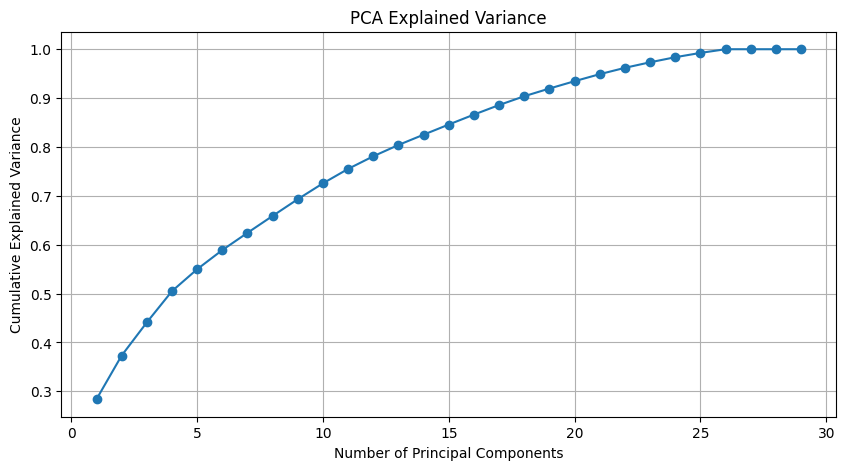

In [48]:
# Explained Variance Plot
plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [49]:
# PCA with 2 Components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Reduced Shape:", X_pca.shape)

Reduced Shape: (2240, 2)


In [50]:
# PCA DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,4.446372,-0.171484
1,-2.781763,-1.225755
2,1.870713,-0.183997
3,-2.977506,1.865710
4,-0.509079,0.739903


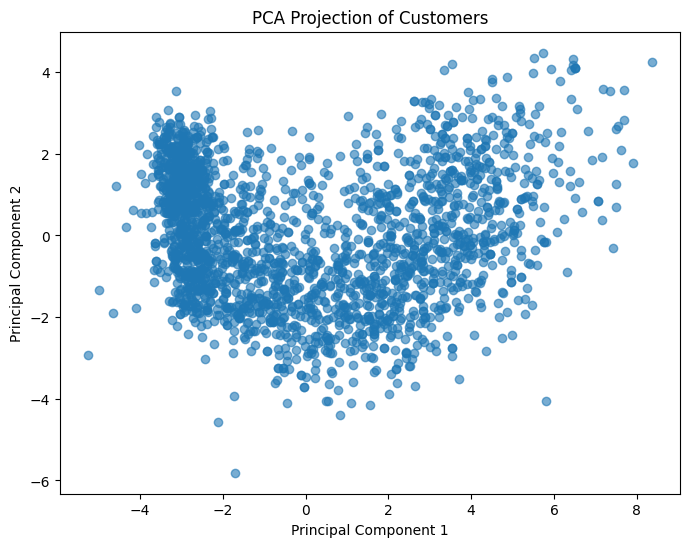

In [51]:
# PCA Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Projection of Customers")

plt.show()

In [52]:
# Variance Explained
print("PC1 Variance:", pca.explained_variance_ratio_[0])
print("PC2 Variance:", pca.explained_variance_ratio_[1])

print("Total Variance:",
      pca.explained_variance_ratio_.sum())

PC1 Variance: 0.28394008062686205
PC2 Variance: 0.0894031125506032
Total Variance: 0.3733431931774652


In [ ]:
# Principal Component Analysis (PCA)

# Principal Component Analysis (PCA) was applied to the standardized dataset to reduce the original 29 features into two principal components.

# The explained variance ratio was analyzed to understand how much information was retained after dimensionality reduction.

# Reducing the dataset to two dimensions makes it easier to visualize customer groups and prepares the data for K-Means clustering.

In [53]:
# Elbow Method
wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    wcss.append(kmeans.inertia_)

print("WCSS Calculated Successfully!")

WCSS Calculated Successfully!


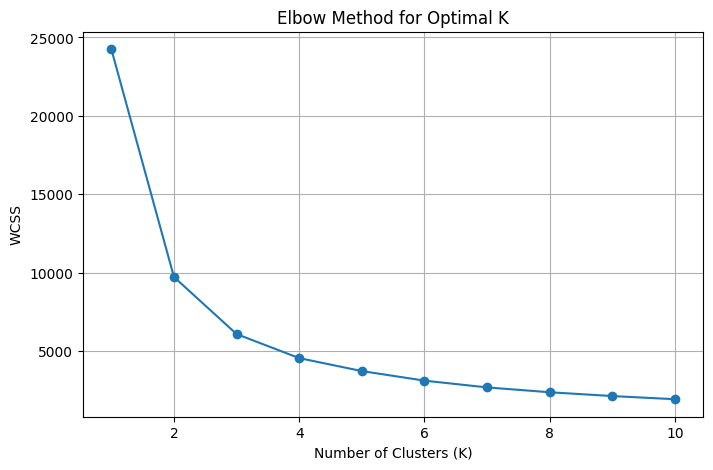

In [54]:
# Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.title("Elbow Method for Optimal K")

plt.grid(True)

plt.show()

In [55]:
# WCSS Values
for k, value in zip(range(1,11), wcss):
    print(f"K = {k}  --->  WCSS = {value:.2f}")

K = 1  --->  WCSS = 24252.37
K = 2  --->  WCSS = 9727.38
K = 3  --->  WCSS = 6089.72
K = 4  --->  WCSS = 4556.80
K = 5  --->  WCSS = 3730.22
K = 6  --->  WCSS = 3120.38
K = 7  --->  WCSS = 2688.20
K = 8  --->  WCSS = 2379.74
K = 9  --->  WCSS = 2137.08
K = 10  --->  WCSS = 1935.47


In [ ]:
# Elbow Method

# The Elbow Method was applied to determine the optimal number of customer clusters.

# The Within-Cluster Sum of Squares (WCSS) was calculated for cluster values ranging from 1 to 10.

# The optimal number of clusters was identified by locating the point where adding additional clusters resulted in only marginal reductions in WCSS.

In [56]:
# Silhouette Scores
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    silhouette_scores.append(score)

print("Silhouette Scores Calculated!")

Silhouette Scores Calculated!


In [57]:
# Print Scores
for k, score in zip(range(2,11), silhouette_scores):

    print(f"K = {k} ---> Silhouette Score = {score:.4f}")

K = 2 ---> Silhouette Score = 0.5257
K = 3 ---> Silhouette Score = 0.4682
K = 4 ---> Silhouette Score = 0.4182
K = 5 ---> Silhouette Score = 0.3892
K = 6 ---> Silhouette Score = 0.4064
K = 7 ---> Silhouette Score = 0.3917
K = 8 ---> Silhouette Score = 0.3988
K = 9 ---> Silhouette Score = 0.4009
K = 10 ---> Silhouette Score = 0.3563


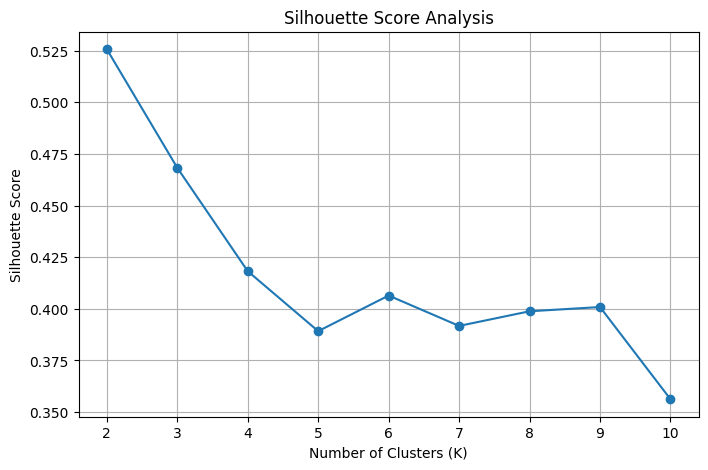

In [58]:
# Silhouette Plot
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Score Analysis")

plt.grid(True)

plt.show()

In [59]:
# Best K
best_k = range(2,11)[np.argmax(silhouette_scores)]

print("Best Number of Clusters:", best_k)

Best Number of Clusters: 2


In [ ]:
# Silhouette Score

# The Silhouette Score was computed for cluster sizes ranging from 2 to 10.

# This metric evaluates how well-separated the resulting clusters are by comparing the similarity of each sample to its own cluster versus other clusters.

# The number of clusters with the highest Silhouette Score was selected as the optimal value for K-Means clustering.

In [60]:
# Final K-Means Model
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

print("K-Means Model Trained Successfully!")

K-Means Model Trained Successfully!


In [61]:
# Add Cluster Labels
df_clustered = df_clean.copy()

df_clustered["Cluster"] = clusters

df_clustered.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For_Days,Total_Spending,Total_Purchases,Age,Cluster
0,1957,2,4,58138.0,0,0,58,635,88,546,...,0,0,0,0,1,663,1617,22,69,1
1,1954,2,4,46344.0,1,1,38,11,1,6,...,0,0,0,0,0,113,27,4,72,0
2,1965,2,5,71613.0,0,0,26,426,49,127,...,0,0,0,0,0,312,776,20,61,1
3,1984,2,5,26646.0,1,0,26,11,4,20,...,0,0,0,0,0,139,53,6,42,0
4,1981,4,3,58293.0,1,0,94,173,43,118,...,0,0,0,0,0,161,422,14,45,0


In [62]:
# Cluster Sizes
print(df_clustered["Cluster"].value_counts())

Cluster
0    1308
1     932
Name: count, dtype: int64


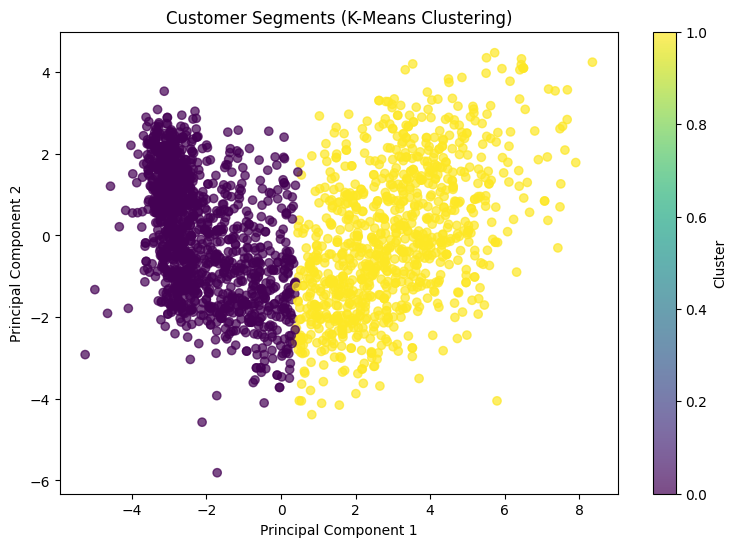

In [63]:
# Cluster Visualization
plt.figure(figsize=(9,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments (K-Means Clustering)")

plt.colorbar(label="Cluster")

plt.show()

In [64]:
# Cluster Statistics
cluster_summary = df_clustered.groupby("Cluster").mean()

cluster_summary

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For_Days,Total_Spending,Total_Purchases,Age
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1970.315749,2.336391,3.719419,38501.750000,0.708716,0.544343,48.941896,89.249235,6.719419,35.632263,...,0.026758,0.000000,0.005352,0.001529,0.010703,0.091743,336.016055,169.811162,7.517584,55.684251
1,1966.686695,2.474249,3.744635,71515.854077,0.072961,0.452790,49.344421,605.233906,53.785408,351.245708,...,0.141631,0.174893,0.146996,0.030043,0.007511,0.229614,378.234979,1217.677039,19.581545,59.313305


In [65]:
# Important Features
cluster_summary[
    [
        "Income",
        "Age",
        "Total_Spending",
        "Total_Purchases",
        "Recency"
    ]
]

,Income,Age,Total_Spending,Total_Purchases,Recency
Cluster,,,,,
0,38501.750000,55.684251,169.811162,7.517584,48.941896
1,71515.854077,59.313305,1217.677039,19.581545,49.344421


In [ ]:
# Final K-Means Clustering

# The final K-Means clustering model was trained using the optimal number of clusters determined through Silhouette Score analysis.

# Each customer was assigned to a cluster, and the resulting groups were analyzed based on their demographic and purchasing characteristics.

# The cluster profiles were then used to develop meaningful customer personas for business decision-making.

In [66]:
# Save Clustered Dataset
df_clustered.to_csv(
    "Customer_Segmentation_Result.csv",
    index=False
)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [67]:
from google.colab import files

files.download("Customer_Segmentation_Result.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
import joblib

joblib.dump(kmeans, "kmeans_customer_segmentation.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [69]:
files.download("kmeans_customer_segmentation.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Project Summary

# A complete customer segmentation pipeline is developed using unsupervised machine learning techniques.
# The dataset was cleaned, engineered with additional features, standardized, and reduced to two dimensions using Principal Component Analysis (PCA).
# The Elbow Method and Silhouette Score were applied to determine the optimal number of clusters, and K-Means clustering was used to segment customers into two meaningful groups.
# The resulting customer personas provide actionable business insights that can support targeted marketing strategies, customer retention, and personalized promotions.